In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

DATA_DIR = "D:\wetransfer_ie-challenge_2025-12-03_1651\IE_1_StyleHub360_Data"

In [2]:
# 2. LOAD & PREPARE DATA
# Load the customer file
df = pd.read_csv(f"{DATA_DIR}/customer_data.csv")

# Select the features for clustering
# We use the raw scores (1-5) provided in the dataset
features = ['recency_score', 'frequency_score', 'monetary_score']
X = df[features]

# Standardizes features so one doesn't dominate (e.g., Spend vs. Frequency)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
# 3. RUN K-MEANS CLUSTERING
# We choose k=5 to create more granular segments than the existing 3 tiers
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster_label'] = kmeans.fit_predict(X_scaled)

c:\Users\Rasheed\anaconda3\envs\math103cpu_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [ ]:
# 4. CLUSTER PROFILING
# Group by cluster to see the average behavior of each group
profile = df.groupby('cluster_label')[features].mean()
print("CLUSTER PROFILES (Mean Scores)")
print(profile)

CLUSTER PROFILES (Mean Scores)
               recency_score  frequency_score  monetary_score
cluster_label                                                
0                   1.416058         1.715328        1.642336
1                   4.299213         4.590551        4.708661
2                   4.484375         2.734375        3.046875
3                   3.519481         1.727273        1.623377
4                   2.136842         3.936842        3.757895


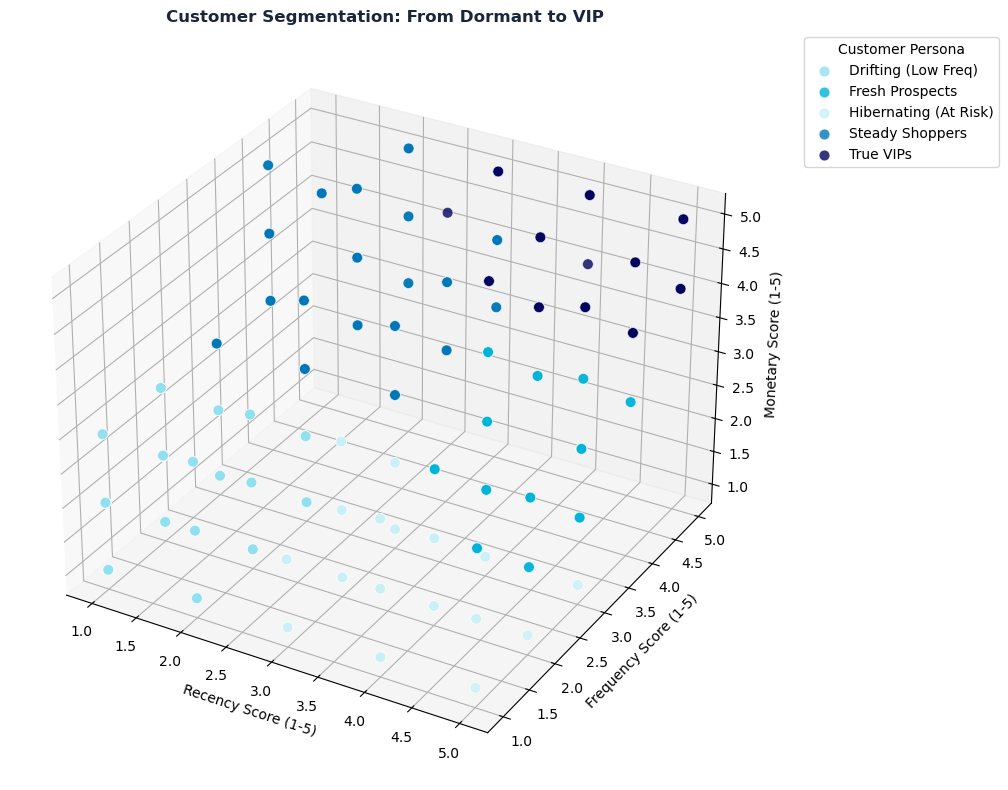

<Figure size 640x480 with 0 Axes>

In [10]:
# 5. VISUALIZATION (Blue Gradient 3D Scatter Plot)
cluster_stats = df.groupby('cluster_label')[['recency_score', 'frequency_score', 'monetary_score']].mean()
sorted_ids = cluster_stats.sort_values('monetary_score', ascending=True).index

# Map the sorted IDs to our Descriptive Names
label_mapping = {
    sorted_ids[0]: 'Hibernating (At Risk)',    # Lowest Value
    sorted_ids[1]: 'Drifting (Low Freq)',      # Low-Mid Value
    sorted_ids[2]: 'Fresh Prospects',          # Mid Value
    sorted_ids[3]: 'Steady Shoppers',          # Mid-High Value
    sorted_ids[4]: 'True VIPs'                 # Highest Value
}

# Create the new column in the dataframe
df['Segment'] = df['cluster_label'].map(label_mapping)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {
    'Hibernating (At Risk)': '#caf0f8', 
    'Drifting (Low Freq)': '#90e0ef', 
    'Fresh Prospects': '#00b4d8',    
    'Steady Shoppers': "#0077b6",
    'True VIPs': '#03045e'
}

for name, group in df.groupby('Segment'):
    ax.scatter(
        group['recency_score'], 
        group['frequency_score'], 
        group['monetary_score'], 
        c=colors.get(name, 'gray'), 
        label=name,                
        s=60, 
        alpha=0.8,
        edgecolor='white',
        linewidth=0.5
    )

# Labeling
ax.set_xlabel('Recency Score (1-5)')
ax.set_ylabel('Frequency Score (1-5)')
ax.set_zlabel('Monetary Score (1-5)')
ax.set_title('Customer Segmentation: From Dormant to VIP', fontsize=12, fontweight='bold', color='#1b263b')

# Add the legend outside the plot
ax.legend(title="Customer Persona", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
ax.legend(title="Customer Persona", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()